# Expanding-window ML: recency δ=0.999 vs no-recency δ=1.0 — individual then ensemble (MCS)

Does the recency weight help the **expanding-window** trees? With an expanding window the
training set grows to ~4k rows, so δ=0.999 down-weights old data heavily (δ^4000≈0.02),
partly fighting the 'use all the data' idea. Here we run each tree learner **twice on the
expanding window** — with recency (δ=0.999) and without (δ=1.0) — and compare. HAR stays
the rolling-6y δ=0.999 benchmark; common OOS starts at year 6; QLIKE in levels.

**Ensembling** = equal-weight, forecast-level mean of three level forecasts:
`f_ens(t) = (f_har18(t) + f_xgb(t) + f_lgb(t)) / 3` (only the point forecasts are averaged).

Stages: **(1) individual** (3 HAR + xgb/lgb rec + xgb/lgb norec), then **(2) ensemble**
(`ens_rec`, `ens_norec`).

In [1]:
# ===========================================================================
# Cell 1 — Thread caps, imports, data, constants
# ===========================================================================
import os
for _v in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ[_v] = "2"
import importlib.util, subprocess, time, itertools
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

def _import_lightgbm():
    try:
        import lightgbm as lgb; return lgb
    except OSError:
        import sklearn
        sk  = os.path.join(os.path.dirname(sklearn.__file__), ".dylibs")
        lib = os.path.join(os.path.dirname(importlib.util.find_spec("lightgbm").origin),
                           "lib", "lib_lightgbm.dylib")
        subprocess.run(["install_name_tool", "-add_rpath", sk, lib], check=False)
        import lightgbm as lgb; return lgb
lgb = _import_lightgbm()
from arch.bootstrap import MCS

data = pd.read_parquet("merged_RV_GVZ_with_macro_event.parquet")
rv = data["RV_gold"].astype(float)

TRADING_DAYS = 252
WINDOW = 6 * TRADING_DAYS                                  # 1512 days = 6y (HAR roll; expanding warm-up)
DELTA_REC = 0.999                                         # recency ON
DELTA_NOREC = 1.0                                         # recency OFF (uniform)
DELTA_HAR = 0.999                                         # HAR keeps recency
REFIT_EVERY = 10
EPS = 1e-6
THREADS_PER_MODEL = 2

print(f"RV_gold: {len(rv)} obs, {rv.index.min().date()} .. {rv.index.max().date()}")
print(f"WINDOW={WINDOW} (6y) | DELTA_REC={DELTA_REC} | DELTA_NOREC={DELTA_NOREC} | "
      f"threads/model={THREADS_PER_MODEL} | xgb {xgb.__version__} | lgb {lgb.__version__}")

RV_gold: 4015 obs, 2010-06-08 .. 2026-05-29
WINDOW=1512 (6y) | DELTA_REC=0.999 | DELTA_NOREC=1.0 | threads/model=2 | xgb 3.2.0 | lgb 4.6.0


In [2]:
# ===========================================================================
# Cell 2 — Design tables
# ===========================================================================
for col in ["RV_gold", "GVZ_close", "RV_ES", "RV_crude"]:
    assert (data[col] > 0).all(), f"{col} has non-positive values; log undefined"

x = np.log(rv)

def build_log_design(extra_cols):
    df = pd.DataFrame(index=rv.index)
    df["x_d"] = x
    df["x_w"] = x.rolling(5).mean()
    df["x_m"] = x.rolling(22).mean()
    for name, series in extra_cols.items():
        df[name] = series.reindex(rv.index)
    df["y_log"]   = x.shift(-1)
    df["y_level"] = rv.shift(-1)
    return df.dropna()

log_gvz   = np.log(data["GVZ_close"])
log_spx   = np.log(data["RV_ES"])
log_crude = np.log(data["RV_crude"])
macro     = data["macro_event"].shift(-1).astype(float)

d_gvz_macro       = build_log_design({"log_GVZ": log_gvz, "macro": macro})
d_crude_gvz_macro = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude, "macro": macro})
d_spx_gvz_macro   = build_log_design({"log_GVZ": log_gvz, "log_RV_ES": log_spx, "macro": macro})
d_all_macro       = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude,
                                      "log_RV_ES": log_spx, "macro": macro})
for d in (d_crude_gvz_macro, d_spx_gvz_macro, d_all_macro):
    assert d_gvz_macro.index.equals(d.index)
feats_rich = ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude", "log_RV_ES", "macro"]
print("designs rows:", len(d_gvz_macro))

designs rows: 3993


In [3]:
# ===========================================================================
# Cell 3 — Helpers + HAR forecasts (rolling 6y, delta=0.999). OOS starts year 6.
# ===========================================================================
START_DATE = d_gvz_macro.index[WINDOW]

def _recency_weights(n, delta):
    if delta >= 1.0:
        return np.ones(n)
    ages = np.arange(n)[::-1]
    w = delta ** ages
    return w * (n / w.sum())

def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps)
    r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

def rolling_log_ols_forecast_series(design, feat_cols, window=WINDOW, delta=DELTA_HAR, start_date=None):
    if start_date is None:
        start_date = START_DATE
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl = design["y_log"].to_numpy(); idx = design.index; N, p = X.shape
    t_oos = np.arange(window, N)[idx[window:] >= start_date]; starts = t_oos - window
    Xwins = np.lib.stride_tricks.sliding_window_view(X, window, axis=0)[starts].transpose(0, 2, 1)
    ywins = np.lib.stride_tricks.sliding_window_view(yl, window)[starts]
    w = _recency_weights(window, delta); sw = np.sqrt(w)
    Xs = Xwins * sw[None, :, None]; ys = ywins * sw[None, :]
    beta = np.linalg.solve(np.einsum("nwi,nwj->nij", Xs, Xs), np.einsum("nwi,nw->ni", Xs, ys))
    fitted = np.einsum("nwp,np->nw", Xwins, beta)
    smear = np.einsum("nw,w->n", np.exp(ywins - fitted), w) / w.sum()
    fc = np.exp(np.einsum("np,np->n", X[t_oos], beta)) * smear
    return pd.Series(fc, index=idx[t_oos], name="forecast")

f_har18 = rolling_log_ols_forecast_series(d_gvz_macro,       ["x_d", "x_w", "x_m", "log_GVZ", "macro"])
f_har19 = rolling_log_ols_forecast_series(d_spx_gvz_macro,   ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES", "macro"])
f_har20 = rolling_log_ols_forecast_series(d_crude_gvz_macro, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude", "macro"])
actual = d_gvz_macro["y_level"].reindex(f_har18.index)
print(f"Common OOS: {f_har18.index.min().date()} .. {f_har18.index.max().date()}  (n={len(f_har18)})")
print("HAR mean QLIKE:", {k: round(float(_qlike(actual.values, fv.values)[0].mean()), 6)
                          for k, fv in [("har_run18", f_har18), ("har_run19", f_har19), ("har_run20", f_har20)]})

Common OOS: 2016-07-11 .. 2026-05-28  (n=2481)
HAR mean QLIKE: {'har_run18': 0.027947, 'har_run19': 0.027931, 'har_run20': 0.027866}


In [4]:
# ===========================================================================
# Cell 4 — XGBoost machinery + expanding/rolling forecast fn (delta arg)
# ===========================================================================
MARGIN_CLIP = (-2.0, 8.0)
ESR, CAP = 30, 500
WF_EDGES = [0.20, 0.40, 0.60, 0.80, 1.00]
XGB_GRID = [dict(max_depth=md, eta=lr, subsample=0.8, colsample_bytree=0.8,
                 min_child_weight=5, reg_lambda=1.0, tree_method="hist", nthread=THREADS_PER_MODEL)
            for md, lr in itertools.product([2, 3, 4], [0.03, 0.1])]

def _xgb_make_obj(w):
    def obj(preds, dtrain):
        y = dtrain.get_label(); f = np.exp(np.clip(preds, *MARGIN_CLIP))
        return w * (1.0 - y / f), w * (y / f)
    return obj

def _xgb_qlike_feval(preds, dmat):
    y = dmat.get_label(); f = np.maximum(np.exp(np.clip(preds, *MARGIN_CLIP)), EPS); r = y / f
    return "qlike", float(np.mean(r - np.log(r) - 1.0))

def _xgb_fit_window(Xw, yw, delta):
    n = len(Xw); w_full = _recency_weights(n, delta)
    edges = [int(round(f * n)) for f in WF_EDGES]
    folds = [(0, edges[k], edges[k + 1]) for k in range(4)]
    chosen = []
    for tr0, v0, v1 in folds:
        Xtr, ytr = Xw[tr0:v0], yw[tr0:v0]; Xvl, yvl = Xw[v0:v1], yw[v0:v1]
        wtr = w_full[tr0:v0] * ((v0 - tr0) / w_full[tr0:v0].sum())
        m0 = np.average(np.log(ytr), weights=wtr)
        dtr = xgb.DMatrix(Xtr, label=ytr); dtr.set_base_margin(np.full(len(ytr), m0))
        dvl = xgb.DMatrix(Xvl, label=yvl); dvl.set_base_margin(np.full(len(yvl), m0))
        fb = None
        for params in XGB_GRID:
            bst = xgb.train(params, dtr, num_boost_round=CAP, obj=_xgb_make_obj(wtr),
                            custom_metric=_xgb_qlike_feval, evals=[(dvl, "val")],
                            early_stopping_rounds=ESR, maximize=False, verbose_eval=False)
            if fb is None or bst.best_score < fb[0]:
                fb = (bst.best_score, params, bst.best_iteration)
        chosen.append(fb)
    m0f = np.average(np.log(yw), weights=w_full)
    dall = xgb.DMatrix(Xw, label=yw); dall.set_base_margin(np.full(n, m0f))
    boosters = [xgb.train(p, dall, num_boost_round=max(int(bi) + 1, 1),
                          obj=_xgb_make_obj(w_full), verbose_eval=False)
                for (_, p, bi) in chosen]
    return boosters, m0f

def _xgb_predict_ens(boosters, m0f, Xrows):
    fs = []
    for bst in boosters:
        d = xgb.DMatrix(Xrows); d.set_base_margin(np.full(len(Xrows), m0f))
        fs.append(np.exp(np.clip(bst.predict(d), *MARGIN_CLIP)))
    return np.mean(fs, axis=0)

def rolling_xgb_cv_forecast_series(design, feat_cols, window=WINDOW, delta=DELTA_REC,
                                   refit_every=REFIT_EVERY, start_date=None, label="", expanding=False):
    if start_date is None:
        start_date = START_DATE
    Xall = design[feat_cols].to_numpy(); lvl = design["y_level"].to_numpy(); idx = design.index
    N = len(design); t_oos = np.arange(window, N)[idx[window:] >= start_date]
    fc = np.empty(len(t_oos)); t0 = time.time()
    for p0 in range(0, len(t_oos), refit_every):
        r = t_oos[p0]; lo = 0 if expanding else r - window
        boosters, m0f = _xgb_fit_window(Xall[lo:r], lvl[lo:r], delta)
        block = t_oos[p0:p0 + refit_every]
        fc[p0:p0 + refit_every] = _xgb_predict_ens(boosters, m0f, Xall[block])
    print(f"[{label}] done elapsed={time.time()-t0:.0f}s  (expanding={expanding}, delta={delta})")
    return pd.Series(fc, index=idx[t_oos], name="forecast")
print("XGB machinery ready.")

XGB machinery ready.


In [5]:
# ===========================================================================
# Cell 5 — LightGBM machinery + expanding/rolling forecast fn (delta arg)
# ===========================================================================
LGB_DEPTH_LEAVES = [(2, 4), (3, 7), (4, 15)]
LGB_MIN_DATA     = [20, 50, 100]
LGB_GRID = [dict(max_depth=md, num_leaves=nl, min_data_in_leaf=mdl, learning_rate=0.05,
                 feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                 verbosity=-1, num_threads=THREADS_PER_MODEL, seed=0)
            for (md, nl) in LGB_DEPTH_LEAVES for mdl in LGB_MIN_DATA]
LGB_DS = {"feature_pre_filter": False}

def _lgb_make_obj(w):
    def obj(preds, ds):
        y = ds.get_label(); f = np.exp(np.clip(preds, *MARGIN_CLIP))
        return w * (1.0 - y / f), w * (y / f)
    return obj

def _lgb_qlike_feval(preds, ds):
    y = ds.get_label(); f = np.maximum(np.exp(np.clip(preds, *MARGIN_CLIP)), EPS); r = y / f
    return "qlike", float(np.mean(r - np.log(r) - 1.0)), False

def _lgb_fit_window(Xw, yw, delta):
    n = len(Xw); w_full = _recency_weights(n, delta)
    edges = [int(round(f * n)) for f in WF_EDGES]
    folds = [(0, edges[k], edges[k + 1]) for k in range(4)]
    chosen = []
    for tr0, v0, v1 in folds:
        Xtr, ytr = Xw[tr0:v0], yw[tr0:v0]; Xvl, yvl = Xw[v0:v1], yw[v0:v1]
        wtr = w_full[tr0:v0] * ((v0 - tr0) / w_full[tr0:v0].sum())
        m0 = np.average(np.log(ytr), weights=wtr)
        dtr = lgb.Dataset(Xtr, label=ytr, init_score=np.full(len(ytr), m0),
                          params=LGB_DS, free_raw_data=False)
        dvl = lgb.Dataset(Xvl, label=yvl, init_score=np.full(len(yvl), m0),
                          reference=dtr, params=LGB_DS, free_raw_data=False)
        fb = None
        for params in LGB_GRID:
            bst = lgb.train(dict(params, objective=_lgb_make_obj(wtr)), dtr, num_boost_round=CAP,
                            valid_sets=[dvl], valid_names=["val"], feval=_lgb_qlike_feval,
                            callbacks=[lgb.early_stopping(ESR, verbose=False), lgb.log_evaluation(0)])
            sc = bst.best_score["val"]["qlike"]
            if fb is None or sc < fb[0]:
                fb = (sc, params, bst.best_iteration)
        chosen.append(fb)
    m0f = np.average(np.log(yw), weights=w_full)
    dall = lgb.Dataset(Xw, label=yw, init_score=np.full(n, m0f), params=LGB_DS, free_raw_data=False)
    boosters = [lgb.train(dict(p, objective=_lgb_make_obj(w_full)), dall,
                          num_boost_round=max(int(bi), 1), callbacks=[lgb.log_evaluation(0)])
                for (_, p, bi) in chosen]
    return boosters, m0f

def _lgb_predict_ens(boosters, m0f, Xrows):
    fs = [np.exp(np.clip(m0f + bst.predict(Xrows, raw_score=True), *MARGIN_CLIP)) for bst in boosters]
    return np.mean(fs, axis=0)

def rolling_lgb_cv_forecast_series(design, feat_cols, window=WINDOW, delta=DELTA_REC,
                                   refit_every=REFIT_EVERY, start_date=None, label="", expanding=False):
    if start_date is None:
        start_date = START_DATE
    Xall = design[feat_cols].to_numpy(); lvl = design["y_level"].to_numpy(); idx = design.index
    N = len(design); t_oos = np.arange(window, N)[idx[window:] >= start_date]
    fc = np.empty(len(t_oos)); t0 = time.time()
    for p0 in range(0, len(t_oos), refit_every):
        r = t_oos[p0]; lo = 0 if expanding else r - window
        boosters, m0f = _lgb_fit_window(Xall[lo:r], lvl[lo:r], delta)
        block = t_oos[p0:p0 + refit_every]
        fc[p0:p0 + refit_every] = _lgb_predict_ens(boosters, m0f, Xall[block])
    print(f"[{label}] done elapsed={time.time()-t0:.0f}s  (expanding={expanding}, delta={delta})")
    return pd.Series(fc, index=idx[t_oos], name="forecast")
print("LGB machinery ready.")

LGB machinery ready.


In [6]:
# ===========================================================================
# Cell 6 — Run the 4 expanding tree models (2 learners x {rec, norec}), parallel
# ===========================================================================
jobs = {
    "xgb_exp_rec":   (rolling_xgb_cv_forecast_series, dict(expanding=True, delta=DELTA_REC)),
    "xgb_exp_norec": (rolling_xgb_cv_forecast_series, dict(expanding=True, delta=DELTA_NOREC)),
    "lgb_exp_rec":   (rolling_lgb_cv_forecast_series, dict(expanding=True, delta=DELTA_REC)),
    "lgb_exp_norec": (rolling_lgb_cv_forecast_series, dict(expanding=True, delta=DELTA_NOREC)),
}
t0 = time.time()
with ThreadPoolExecutor(max_workers=2) as ex:
    futs = {n: ex.submit(fn, d_all_macro, feats_rich, label=n, **kw) for n, (fn, kw) in jobs.items()}
    F = {n: futs[n].result() for n in jobs}
print(f"all tree models done in {time.time()-t0:.0f}s")

[xgb_exp_norec] done elapsed=478s  (expanding=True, delta=1.0)


[xgb_exp_rec] done elapsed=487s  (expanding=True, delta=0.999)


[lgb_exp_rec] done elapsed=217s  (expanding=True, delta=0.999)


[lgb_exp_norec] done elapsed=214s  (expanding=True, delta=1.0)
all tree models done in 701s


In [7]:
# ===========================================================================
# Cell 7 — INDIVIDUAL performance (MCS #1): 7 models
# ===========================================================================
forecasts = pd.DataFrame({
    "har_run18": f_har18, "har_run19": f_har19, "har_run20": f_har20,
    "xgb_exp_rec": F["xgb_exp_rec"], "xgb_exp_norec": F["xgb_exp_norec"],
    "lgb_exp_rec": F["lgb_exp_rec"], "lgb_exp_norec": F["lgb_exp_norec"],
}).dropna()
act = actual.reindex(forecasts.index).values
losses_ind = pd.DataFrame({m: _qlike(act, forecasts[m].values)[0] for m in forecasts.columns},
                          index=forecasts.index)
assert losses_ind.notna().all().all()
forecasts.to_parquet("expandingml_recency_forecasts.parquet")
losses_ind.to_parquet("expandingml_recency_losses.parquet")

pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print(f"OOS days: {len(losses_ind)}  ({losses_ind.index.min().date()} .. {losses_ind.index.max().date()})\n")
print("Mean QLIKE (individual, lower=better):")
print(losses_ind.mean().sort_values().rename("mean_qlike").to_frame().to_string())
print("\nRecency vs no-recency (negative = recency better):")
for lr in ("xgb", "lgb"):
    d = losses_ind[f"{lr}_exp_rec"].mean() - losses_ind[f"{lr}_exp_norec"].mean()
    print(f"  {lr}: rec {losses_ind[f'{lr}_exp_rec'].mean():.6f}  -  norec {losses_ind[f'{lr}_exp_norec'].mean():.6f}  =  {d:+.6f}")

mcs_ind = MCS(losses_ind, size=0.05, reps=10000, block_size=None,
              method="R", bootstrap="stationary", seed=42)
mcs_ind.compute()
res_ind = (pd.DataFrame({"mean_qlike": losses_ind.mean(), "mcs_pvalue": mcs_ind.pvalues["Pvalue"]})
           .assign(in_mcs=lambda d: d["mcs_pvalue"] > 0.05).sort_values("mean_qlike"))
res_ind.to_parquet("mcs_expandingml_recency_individual.parquet")
print("\n=== Individual MCS ==="); print(res_ind.to_string())
res_ind

OOS days: 2481  (2016-07-11 .. 2026-05-28)

Mean QLIKE (individual, lower=better):
               mean_qlike
har_run20        0.027866
har_run19        0.027931
har_run18        0.027947
xgb_exp_norec    0.029329
xgb_exp_rec      0.029713
lgb_exp_norec    0.030052
lgb_exp_rec      0.030095

Recency vs no-recency (negative = recency better):
  xgb: rec 0.029713  -  norec 0.029329  =  +0.000384
  lgb: rec 0.030095  -  norec 0.030052  =  +0.000043



=== Individual MCS ===
               mean_qlike  mcs_pvalue  in_mcs
har_run20        0.027866    1.000000    True
har_run19        0.027931    0.460900    True
har_run18        0.027947    0.460900    True
xgb_exp_norec    0.029329    0.129900    True
xgb_exp_rec      0.029713    0.129900    True
lgb_exp_norec    0.030052    0.122600    True
lgb_exp_rec      0.030095    0.129900    True


,mean_qlike,mcs_pvalue,in_mcs
har_run20,0.027866,1.000000,True
har_run19,0.027931,0.460900,True
har_run18,0.027947,0.460900,True
xgb_exp_norec,0.029329,0.129900,True
xgb_exp_rec,0.029713,0.129900,True
lgb_exp_norec,0.030052,0.122600,True
lgb_exp_rec,0.030095,0.129900,True


In [8]:
# ===========================================================================
# Cell 8 — ENSEMBLE performance (MCS #2): individuals + equal-weight ensembles
# ===========================================================================
ens = forecasts.copy()
ens["ens_rec"]   = forecasts[["har_run18", "xgb_exp_rec",   "lgb_exp_rec"]].mean(axis=1)
ens["ens_norec"] = forecasts[["har_run18", "xgb_exp_norec", "lgb_exp_norec"]].mean(axis=1)
losses_ens = pd.DataFrame({m: _qlike(act, ens[m].values)[0] for m in ens.columns}, index=ens.index)

print("Mean QLIKE incl. ensembles (lower=better):")
print(losses_ens.mean().sort_values().rename("mean_qlike").to_frame().to_string())
print(f"\nens_rec {losses_ens['ens_rec'].mean():.6f}  vs  ens_norec {losses_ens['ens_norec'].mean():.6f}"
      f"  =  {losses_ens['ens_rec'].mean() - losses_ens['ens_norec'].mean():+.6f}")

mcs_ens = MCS(losses_ens, size=0.05, reps=10000, block_size=None,
              method="R", bootstrap="stationary", seed=42)
mcs_ens.compute()
res_ens = (pd.DataFrame({"mean_qlike": losses_ens.mean(), "mcs_pvalue": mcs_ens.pvalues["Pvalue"]})
           .assign(in_mcs=lambda d: d["mcs_pvalue"] > 0.05).sort_values("mean_qlike"))
res_ens.to_parquet("mcs_expandingml_recency_ensemble.parquet")
print("\n=== Ensemble MCS (9 models) ==="); print(res_ens.to_string())
print(f"\nBest: {res_ens.index[0]}")
print(f"In 5% MCS: {list(res_ens.index[res_ens['in_mcs']])}")
res_ens

Mean QLIKE incl. ensembles (lower=better):
               mean_qlike
har_run20        0.027866
har_run19        0.027931
har_run18        0.027947
ens_norec        0.028503
ens_rec          0.028669
xgb_exp_norec    0.029329
xgb_exp_rec      0.029713
lgb_exp_norec    0.030052
lgb_exp_rec      0.030095

ens_rec 0.028669  vs  ens_norec 0.028503  =  +0.000167



=== Ensemble MCS (9 models) ===
               mean_qlike  mcs_pvalue  in_mcs
har_run20        0.027866    1.000000    True
har_run19        0.027931    0.460900    True
har_run18        0.027947    0.460900    True
ens_norec        0.028503    0.379700    True
ens_rec          0.028669    0.338400    True
xgb_exp_norec    0.029329    0.039800   False
xgb_exp_rec      0.029713    0.039800   False
lgb_exp_norec    0.030052    0.037600   False
lgb_exp_rec      0.030095    0.042300   False

Best: har_run20
In 5% MCS: ['har_run20', 'har_run19', 'har_run18', 'ens_norec', 'ens_rec']


,mean_qlike,mcs_pvalue,in_mcs
har_run20,0.027866,1.000000,True
har_run19,0.027931,0.460900,True
har_run18,0.027947,0.460900,True
ens_norec,0.028503,0.379700,True
ens_rec,0.028669,0.338400,True
xgb_exp_norec,0.029329,0.039800,False
xgb_exp_rec,0.029713,0.039800,False
lgb_exp_norec,0.030052,0.037600,False
lgb_exp_rec,0.030095,0.042300,False


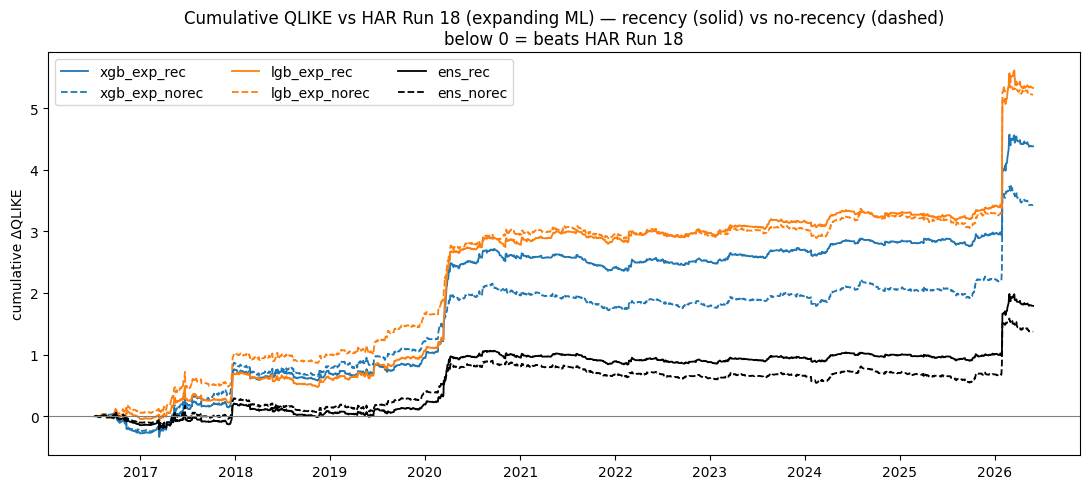

In [9]:
# ===========================================================================
# Cell 9 — Cumulative QLIKE difference vs HAR Run 18 (recency solid, no-recency dashed)
# ===========================================================================
fig, ax = plt.subplots(figsize=(11, 5))
series = [("xgb_exp_rec", "C0", "-"), ("xgb_exp_norec", "C0", "--"),
          ("lgb_exp_rec", "C1", "-"), ("lgb_exp_norec", "C1", "--"),
          ("ens_rec", "k", "-"), ("ens_norec", "k", "--")]
for name, color, ls in series:
    ax.plot(losses_ens.index, (losses_ens[name] - losses_ens["har_run18"]).cumsum(),
            label=name, color=color, ls=ls, lw=1.3)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Cumulative QLIKE vs HAR Run 18 (expanding ML) \u2014 recency (solid) vs no-recency (dashed)\n"
             "below 0 = beats HAR Run 18")
ax.set_ylabel("cumulative \u0394QLIKE"); ax.legend(ncol=3)
fig.tight_layout(); fig.savefig("expandingml_recency_cum_qlike_6y.png", dpi=150); plt.show()

## MCS conclusions — expanding-window ML, recency δ=0.999 vs no-recency δ=1.0

*Common OOS 2016-07-11 → 2026-05-28 (2,481 days); QLIKE in levels; MCS at the 5% level,
10,000 reps, stationary bootstrap. Trees use an **expanding window** (train on all data
from the start up to each refit origin); HAR is **rolling 6y, δ=0.999**. Forecasts combined
by an **equal-weight average of the three level forecasts** (`har_run18`, the XGB, the LGB).*

**1. HAR is still the model to beat.** The three rolling-6y log-HAR specs occupy the top of
both MCS tables — `har_run20` is best (mean QLIKE **0.027866**, MCS p = 1.00), with
`har_run19` (0.027931) and `har_run18` (0.027947) just behind. No ML model — standalone or
ensembled — overtakes them.

**2. Recency *hurts* the expanding trees; no-recency (δ=1.0) is better.** Removing the
recency weight improves both learners on the expanding window:
- XGBoost: `xgb_exp_norec` **0.029329** < `xgb_exp_rec` 0.029713 (Δ = +0.00038, ~1.3%).
- LightGBM: `lgb_exp_norec` **0.030052** < `lgb_exp_rec` 0.030095 (Δ = +0.00004, negligible).

This is consistent with the rationale for an expanding window: if you deliberately keep all
the accumulated history, weighting it **equally** (δ=1.0) uses that information better than
geometrically down-weighting the oldest rows (at the largest windows δ=0.999 shrinks the
earliest data to ≈2% weight).

**3. The no-recency ensemble is the best non-HAR model.** In the 9-model ensemble MCS the
equal-weight blend **`ens_norec` = mean(har_run18, xgb_exp_norec, lgb_exp_norec)** scores
**0.028503 (p = 0.38)**, edging `ens_rec` 0.028669 (p = 0.34). Both ensembles sit
comfortably inside the 5% MCS and beat every standalone tree; the four standalone tree
models drop out of the set (p ≈ 0.04) once the ensembles and HARs compete with them.

**4. Takeaway.** Combined with the earlier expanding-vs-rolling result, the best ML
configuration is **expanding window + no recency (δ=1.0)** — exactly the "more data, used
equally, helps" intuition. The resulting no-recency ensemble is the closest challenger yet
to the gold-implied-vol HAR (within ~0.0006 QLIKE and statistically indistinguishable from
the best at the 5% level), but the HAR benchmark still holds the top.